# Company Growth — YoY & QoQ

Sales, profit, and order-volume growth for the DataCo transactions file, year-over-year and quarter-over-quarter. Builds on [`0_data_overview.ipynb`](0_data_overview.ipynb).

**Headline finding**: the raw QoQ/YoY numbers show a collapse in the last two quarters — but that collapse is a data-generation artifact, not a business trend (see §2). The clean, like-for-like growth read is in §3.2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'  # diverging pair: blue (growth) <-> red (decline)
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False):
    ax.grid(axis='x' if x_grid else 'y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def pct_fmt(v, _):
    return f'{v:+.0f}%'

DATA_DIR = '.'

## 1. Load & prep

In [2]:
df = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['year'] = df['order date (DateOrders)'].dt.year
df['month'] = df['order date (DateOrders)'].dt.month

print(f"{df.shape[0]:,} order lines, {df['order date (DateOrders)'].min().date()} -> {df['order date (DateOrders)'].max().date()}")

180,519 order lines, 2015-01-01 -> 2018-01-31


## 2. Data quality check: order composition breaks in Oct 2017

Before trusting any growth number, check whether "orders" mean the same thing across the whole date range.

In [3]:
monthly = df.set_index('order date (DateOrders)').resample('MS').agg(
    lines=('Order Id', 'size'),
    orders=('Order Id', 'nunique'),
    sales=('Sales', 'sum'),
).assign(
    items_per_order=lambda d: d['lines'] / d['orders'],
    sales_per_order=lambda d: d['sales'] / d['orders'],
)
monthly.tail(8)

,lines,orders,sales,items_per_order,sales_per_order
order date (DateOrders),,,,,
2017-06-01,4951,1676,1.032086e+06,2.954057,615.803395
2017-07-01,5318,1776,1.104373e+06,2.994369,621.831847
2017-08-01,5305,1768,1.109337e+06,3.000566,627.453151
2017-09-01,5189,1723,1.143775e+06,3.011608,663.827689
2017-10-01,2255,2101,1.073994e+06,1.073298,511.182375
2017-11-01,2055,2055,6.269144e+05,1.000000,305.067827
2017-12-01,2124,2124,5.039108e+05,1.000000,237.246148
2018-01-01,2123,2123,3.316501e+05,1.000000,156.217671


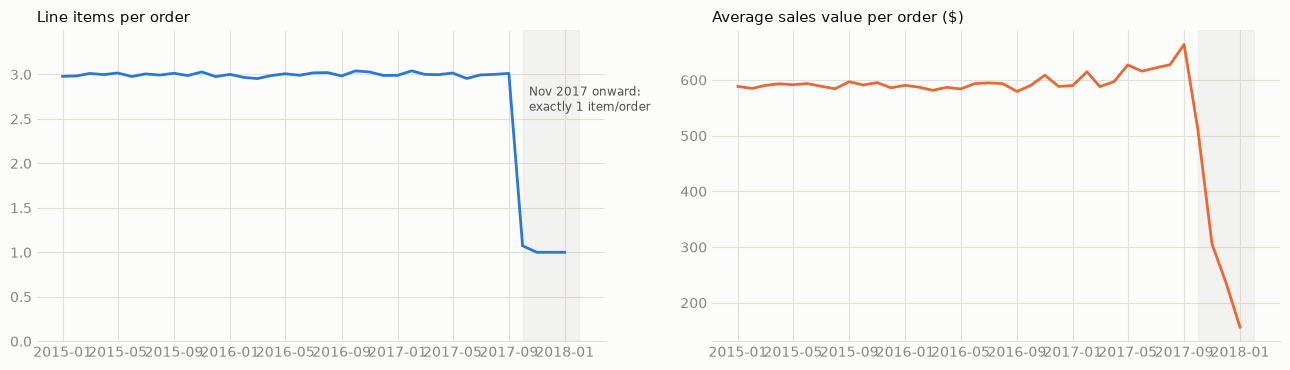

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

ax = axes[0]
ax.plot(monthly.index, monthly['items_per_order'], color=BLUE, linewidth=2)
ax.axvspan(pd.Timestamp('2017-10-01'), monthly.index.max() + pd.Timedelta(days=31), color=INK_MUTED, alpha=0.08)
ax.text(pd.Timestamp('2017-10-15'), monthly['items_per_order'].max() * 0.95, 'Nov 2017 onward:\nexactly 1 item/order',
        color=INK_SECONDARY, fontsize=8.5, va='top')
ax.set_title('Line items per order', loc='left', color=INK, fontsize=11)
ax.set_ylim(0, monthly['items_per_order'].max() * 1.15)
style_axis(ax)

ax = axes[1]
ax.plot(monthly.index, monthly['sales_per_order'], color=ORANGE, linewidth=2)
ax.axvspan(pd.Timestamp('2017-10-01'), monthly.index.max() + pd.Timedelta(days=31), color=INK_MUTED, alpha=0.08)
ax.set_title('Average sales value per order ($)', loc='left', color=INK, fontsize=11)
style_axis(ax)

plt.tight_layout()
plt.show()

Every month from Jan 2015 through Sep 2017 averages ~3.0 line items per order. From **Nov 2017 onward it is flat at exactly 1.0** — every order in the tail of the dataset has a single line item — and average order value falls from ~$620 to ~$156 by Jan 2018. Order *counts* keep pace (even rise) over the same window, so this reads as orders being split into single-item records rather than genuine demand loss.

**Conclusion**: treat **Oct 2017 – Jan 2018** as affected by a data-generation artifact, not a real business swing. It's kept in every chart below (shaded) for transparency, but excluded from the headline growth read in §3.2.

## 3. Year-over-year growth

In [5]:
yearly = df.groupby('year').agg(
    sales=('Sales', 'sum'),
    profit=('Order Profit Per Order', 'sum'),
    orders=('Order Id', 'nunique'),
).round(0)
yearly['sales_yoy_pct'] = yearly['sales'].pct_change() * 100
yearly['coverage'] = 'full'
yearly.loc[yearly.index.max(), 'coverage'] = 'partial (Jan only) + anomaly-affected'
yearly

,sales,profit,orders,sales_yoy_pct,coverage
year,,,,,
2015,12340831.0,1318857.0,20904,NaN,full
2016,12303817.0,1310119.0,20859,-0.299931,full
2017,11808436.0,1304085.0,21866,-4.026238,full
2018,331650.0,33842.0,2123,-97.191415,partial (Jan only) + anomaly-affected


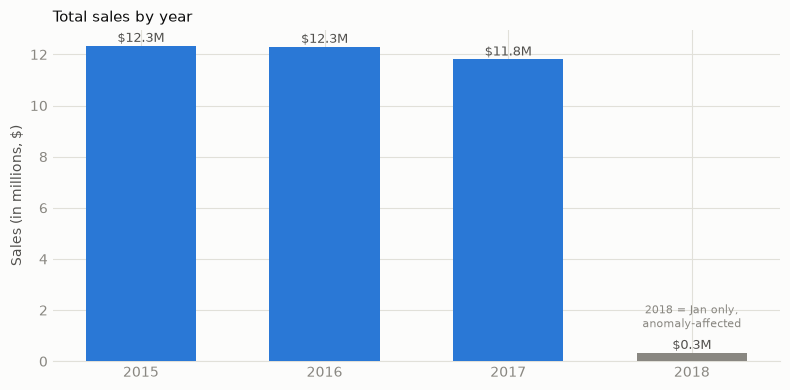

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sales_m = yearly['sales'] / 1e6
colors = [BLUE, BLUE, BLUE, INK_MUTED]  # 2018 muted: partial + anomaly-affected, not comparable
bars = ax.bar(yearly.index.astype(str), sales_m, color=colors[:len(yearly)], width=0.6, zorder=3)
ax.set_ylabel('Sales (in millions, $)')
ax.set_title('Total sales by year', loc='left', color=INK, fontsize=11)
style_axis(ax)
for bar, v in zip(bars, sales_m):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.15, f'${v:.1f}M', ha='center', color=INK_SECONDARY, fontsize=9)
ax.text(3, sales_m.iloc[3] + 1.0, '2018 = Jan only,\nanomaly-affected', ha='center', color=INK_MUTED, fontsize=8)
plt.tight_layout()
plt.show()

Full-year totals make 2017 and 2018 look like a decline — but 2018 is a single month, and 2017's last quarter carries the §2 artifact. Full-year YoY isn't a fair comparison here. The like-for-like version below is.

### 3.2 Like-for-like YoY (Jan–Sep only)

Comparing the same nine months each year sidesteps both the partial-2018 problem and the Q4-2017 artifact.

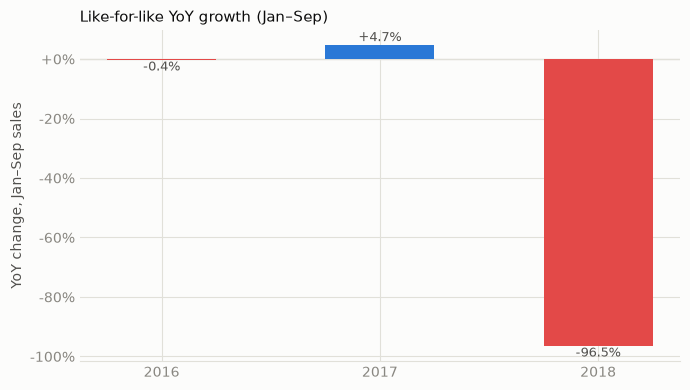

In [7]:
jan_sep = df[df['month'] <= 9].groupby('year')['Sales'].sum()
jan_sep_growth = jan_sep.pct_change() * 100

fig, ax = plt.subplots(figsize=(7, 4))
years = jan_sep_growth.dropna().index.astype(str)
vals = jan_sep_growth.dropna().values
colors = [POS if v >= 0 else NEG for v in vals]
bars = ax.bar(years, vals, color=colors, width=0.5, zorder=3)
ax.axhline(0, color=GRID, linewidth=1)
ax.set_ylabel('YoY change, Jan–Sep sales')
ax.set_title('Like-for-like YoY growth (Jan–Sep)', loc='left', color=INK, fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
style_axis(ax)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + (0.3 if v >= 0 else -0.3), f'{v:+.1f}%',
            ha='center', va='bottom' if v >= 0 else 'top', color=INK_SECONDARY, fontsize=9)
plt.tight_layout()
plt.show()

2016 was essentially flat against 2015 (-0.4%). 2017 grew **+4.7%** against 2016 on a like-for-like basis — the real underlying trend, obscured by the full-year chart above. There isn't enough 2018 data (one month) for a like-for-like 2018 read yet.

## 4. Quarter-over-quarter growth

In [8]:
quarterly = df.set_index('order date (DateOrders)').resample('QS').agg(
    sales=('Sales', 'sum'),
    profit=('Order Profit Per Order', 'sum'),
    orders=('Order Id', 'nunique'),
)
quarterly['qoq_pct'] = quarterly['sales'].pct_change() * 100
quarterly.round(1)

,sales,profit,orders,qoq_pct
order date (DateOrders),,,,
2015-01-01,3029853.7,324579.6,5153,NaN
2015-04-01,3088947.9,330378.7,5211,2.0
2015-07-01,3085914.5,347071.8,5231,-0.1
2015-10-01,3136115.4,316826.8,5309,1.6
2016-01-01,3040704.2,294850.4,5186,-3.0
2016-04-01,3033671.3,329888.8,5159,-0.2
2016-07-01,3096312.9,354056.0,5254,2.1
2016-10-01,3133128.9,331323.9,5260,1.2
2017-01-01,3070237.7,348643.8,5141,-2.0


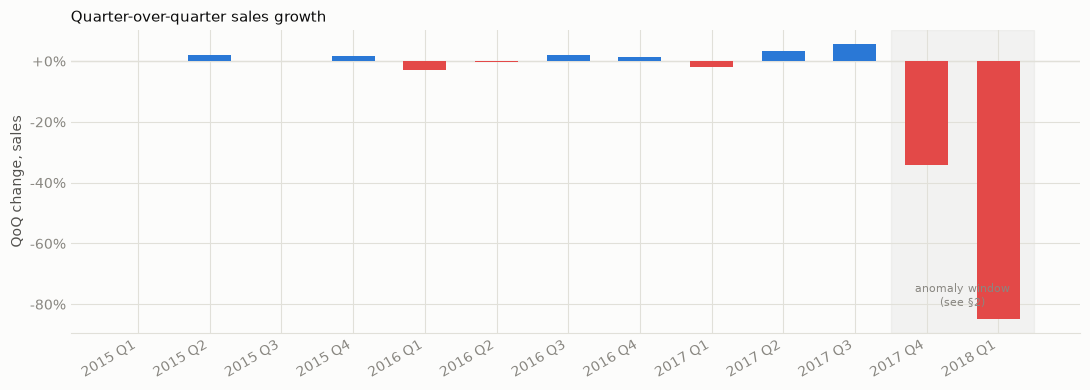

In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
q_labels = [f"{d.year} Q{d.quarter}" for d in quarterly.index]
vals = quarterly['qoq_pct'].values
colors = [INK_MUTED if pd.isna(v) else (POS if v >= 0 else NEG) for v in vals]
bars = ax.bar(q_labels, np.nan_to_num(vals), color=colors, width=0.6, zorder=3)
ax.axhline(0, color=GRID, linewidth=1)
ax.set_ylabel('QoQ change, sales')
ax.set_title('Quarter-over-quarter sales growth', loc='left', color=INK, fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
style_axis(ax)
plt.xticks(rotation=30, ha='right')
ax.axvspan(10.5, 12.5, color=INK_MUTED, alpha=0.08, zorder=0)
ax.text(11.5, ax.get_ylim()[0] * 0.9, 'anomaly window\n(see §2)', ha='center', color=INK_MUTED, fontsize=8)
plt.tight_layout()
plt.show()

Every quarter from 2015 Q1 through 2017 Q3 lands within about ±6% QoQ — a stable, unremarkable pattern, with 2017 Q3 the strongest at **+5.7%**. The final two quarters (2017 Q4: -34%, 2018 Q1: -85%) are the §2 artifact, not a real slowdown.

## Takeaways

- **Real growth signal**: Jan–Sep sales grew **+4.7% in 2017 vs 2016**, after being flat in 2016 vs 2015 (-0.4%). QoQ growth was stable (roughly ±6%) for the first 11 quarters of the dataset.
- **Data caveat**: from Nov 2017 onward, every order collapses to exactly one line item and average order value falls ~75%, while order *counts* hold or rise — a data-generation artifact, not demand collapse. Full-year and late-quarter growth figures are misleading unless this window is excluded or flagged.
- **Recommendation for downstream notebooks**: for any trend, forecast, or growth-rate work, either exclude Oct 2017 onward or model it as a separate regime rather than blending it with the stable Jan 2015–Sep 2017 period.